In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as transforms
import pandas as pd
import numpy as np
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torchvision.transforms.functional import to_pil_image

In [2]:

def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True)

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA
device = torch.device("cuda")

In [3]:

base_transform = transforms.Compose(
    [
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

In [4]:

full_trainset = torchvision.datasets.ImageFolder("trafic_32", transform=base_transform)

train_ratio = 0.8

targets = full_trainset.targets
indices = list(range(len(full_trainset)))

train_indices, val_indices = train_test_split(
    indices,
    train_size=train_ratio,
    stratify=targets,
    random_state=SEED
)

trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

num_classes = len(trainset.dataset.classes)

print(f"Number of classes: {num_classes}")
print(f"Trainset size: {len(trainset)}")
print(f"Validation set size: {len(valset)}")

Number of classes: 43
Trainset size: 31367
Validation set size: 7842


In [5]:
temp_transform = transforms.Compose(
    [
        transforms.Resize(32),
    ]
)

In [ ]:
# all_samples = torch.stack([temp_transform(sample[0]) for sample in trainset])
# mean = all_samples.mean(axis=(0,2,3))
# std=all_samples.std(axis=(0,2,3))
# print(f"Data norm per channel: mean={mean} | std={std}")
# all_samples = None

Data norm per channel: mean=tensor([0.3186, 0.2932, 0.3018]) | std=tensor([0.2762, 0.2654, 0.2686])


In [ ]:
mean = torch.tensor([0.3186, 0.2932, 0.3018])
std = torch.tensor([0.2762, 0.2654, 0.2686])

In [8]:
class WrappedSubset:
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes
        self.targets = [subset.dataset.targets[i] for i in subset.indices]

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [9]:

train_transform = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.Normalize(mean=mean, std=std),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.Normalize(mean=mean, std=std),
    ]
)

trainset = WrappedSubset(trainset, transform=train_transform)
valset = WrappedSubset(valset, transform=test_transform)

In [ ]:
batch_size = 128
shuffle = True
num_workers = 0
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=shuffle,
    num_workers=num_workers,
    pin_memory=True,
    drop_last=True,
    )
valloader = torch.utils.data.DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    )

In [ ]:
## Wczytanie wszystkich danych do GPU - szybszy trening

# all_x = []
# all_y = []
# for x, y in trainset:
#     all_x.append(x)
#     all_y.append(y)

# tensor_x = torch.stack(all_x).to(device)
# tensor_y = torch.tensor(all_y, dtype=torch.int64).to(device) 

# gpu_dataset = torch.utils.data.TensorDataset(tensor_x, tensor_y)

# trainloader = torch.utils.data.DataLoader(
#     gpu_dataset,
#     batch_size=batch_size,
#     shuffle=True, 
#     drop_last=True
# )

In [ ]:
class UNet(nn.Module):
    def __init__(self, num_classes, in_channels=3, out_channels=3):
        super().__init__()

        self.class_emb = nn.Embedding(num_classes, 4)

        # Enkoder
        self.down1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.SiLU()
        )

        self.down2 = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.SiLU()
        )

        self.down3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.SiLU()
        )

        # Dekoder
        self.up1 = nn.Sequential(
                    # down3 + skip2 + t + y_emb
            nn.Conv2d(512 + 256 + 1 + 4, 256, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.SiLU()
        )

        self.up2 = nn.Sequential(
                    # down2 + skip1 + t + y_emb
            nn.Conv2d(256 + 64 + 1 + 4, 64, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.SiLU()
        )

        self.out = nn.Conv2d(64, out_channels, kernel_size=1)

        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    def forward(self, x, t, y):
        t = t.view(-1, 1, 1, 1)
        y_emb = self.class_emb(y).view(-1, 4, 1, 1)

        # Enkoder
        x1 = self.down1(x) # skip connection 1
        x = self.downscale(x1)

        x2 = self.down2(x) # skip connection 2
        x = self.downscale(x2)

        x = self.down3(x)

        # Dekoder
        x = self.upscale(x)
        t_expand1 = t.expand(-1, -1, x.shape[2], x.shape[3])
        y_expand1 = y_emb.expand(-1, -1, x.shape[2], x.shape[3])
        x = torch.cat([x, x2, t_expand1, y_expand1], dim=1)
        x = self.up1(x)

        x = self.upscale(x)
        t_expand2 = t.expand(-1, -1, x.shape[2], x.shape[3])
        y_expand2 = y_emb.expand(-1, -1, x.shape[2], x.shape[3])
        x = torch.cat([x, x1, t_expand2, y_expand2], dim=1)
        x = self.up2(x)

        return self.out(x)

In [ ]:
net = UNet(num_classes=num_classes).to(device)
net

BasicUNet(
  (class_emb): Embedding(43, 4)
  (down1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): SiLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): SiLU()
  )
  (down2): Sequential(
    (0): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): SiLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): SiLU()
  )
  (bottleneck): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): SiLU()
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): SiLU()
  )
  (up1): Sequential(
    (0): Conv2d(773, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): SiLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): SiLU()
  )
  (up2): Sequential(
    (0): Conv2d(325, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Si

In [37]:

def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.randn_like(x)
    amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
    return x*(1-amount) + noise*amount

In [ ]:
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

In [ ]:
n_epochs = 100
losses = []

for epoch in range(n_epochs):
    for x, y in trainloader:

        opt.zero_grad()

        x = x.to(device)
        y = y.to(device)

        noise_amount = torch.rand(x.shape[0]).to(device)
        noisy_x = corrupt(x, noise_amount)

        pred = net(noisy_x, noise_amount, y)

        loss = loss_fn(pred, x) #

        loss.backward()
        opt.step()

        losses.append(loss.item())

    avg_loss = sum(losses[-len(trainloader):])/len(trainloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

plt.plot(losses)

Finished epoch 0. Average loss for this epoch: 0.103317
Finished epoch 1. Average loss for this epoch: 0.102435
Finished epoch 2. Average loss for this epoch: 0.104588
Finished epoch 3. Average loss for this epoch: 0.103754
Finished epoch 4. Average loss for this epoch: 0.102241
Finished epoch 5. Average loss for this epoch: 0.100737
Finished epoch 6. Average loss for this epoch: 0.103804
Finished epoch 7. Average loss for this epoch: 0.102063
Finished epoch 8. Average loss for this epoch: 0.104172
Finished epoch 9. Average loss for this epoch: 0.102209


In [ ]:
def generate_and_show_images(net, class_label, n_steps, n_samples=64):
    
    mean_tensor = mean.detach().view(1, 3, 1, 1).to('cpu')
    std_tensor = std.detach().view(1, 3, 1, 1).to('cpu')

    x = torch.randn(n_samples, 3, 32, 32).to(device)
    y = torch.full((n_samples,), class_label, dtype=torch.long).to(device)

    net.eval()
    for i in range(n_steps):
        t = (torch.zeros(x.size(0)) + (n_steps - i) / n_steps).to(device)

        with torch.no_grad():
            pred = net(x, t, y)

        mix_factor = 1 / (n_steps - i)
        x = x * (1 - mix_factor) + pred * mix_factor

    x_cpu = x.detach().cpu()
    x_denorm = (x_cpu * std_tensor) + mean_tensor

    nrow = int(n_samples**0.5) 
    grid = torchvision.utils.make_grid(x_denorm, nrow=nrow).clip(0, 1)

    img = to_pil_image(grid)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(np.asarray(img))
    plt.axis('off')
    plt.title(f'Wygenerowane obrazy (Kroki: {n_steps})')
    plt.tight_layout()
    plt.show()
    
    return x_denorm

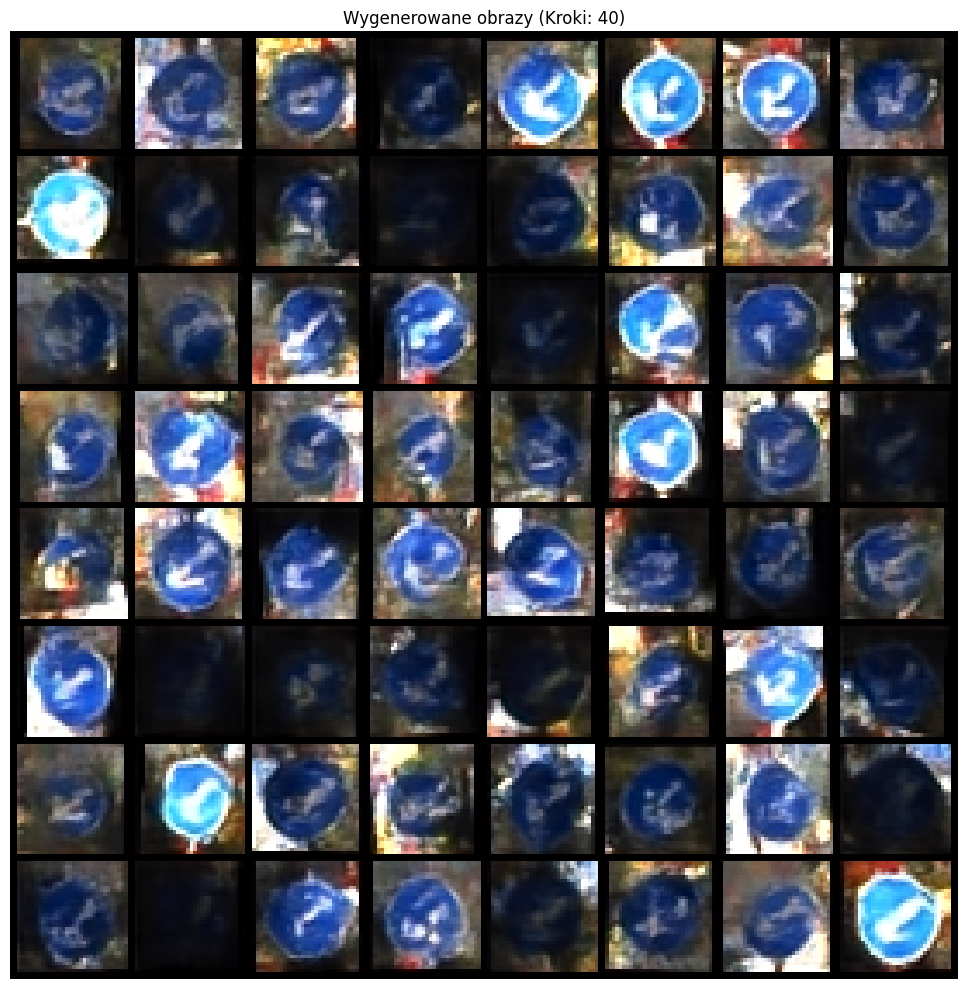

tensor([[[[ 4.9906e-02,  2.6834e-01,  2.7711e-01,  ...,  3.6864e-01,
            4.5397e-02,  3.7225e-03],
          [ 3.7179e-02,  2.5740e-01,  2.9004e-01,  ...,  3.1486e-01,
            4.8826e-02,  1.9564e-02],
          [ 2.9696e-02,  2.6023e-01,  2.8531e-01,  ...,  2.8523e-01,
            1.5161e-02,  5.5432e-03],
          ...,
          [ 2.8365e-02,  1.9492e-01,  2.3114e-01,  ...,  1.0540e-01,
           -4.5954e-03,  8.8120e-04],
          [ 2.5764e-02,  1.3392e-01,  1.6755e-01,  ...,  9.4139e-02,
            2.3491e-03, -7.5343e-03],
          [ 1.9871e-02,  1.4518e-01,  1.8558e-01,  ...,  8.0691e-02,
            4.2492e-03, -1.1376e-03]],

         [[ 2.1496e-02,  2.1898e-01,  2.0892e-01,  ...,  3.3487e-01,
            2.6862e-02, -1.4136e-03],
          [ 9.6611e-03,  2.1464e-01,  2.2849e-01,  ...,  2.7591e-01,
            3.1007e-02,  1.1088e-02],
          [ 8.2432e-03,  2.2523e-01,  2.2503e-01,  ...,  2.5682e-01,
            6.0841e-03, -8.6409e-04],
          ...,
     

In [ ]:
generate_and_show_images(net, class_label=39, n_steps=40, n_samples=64)

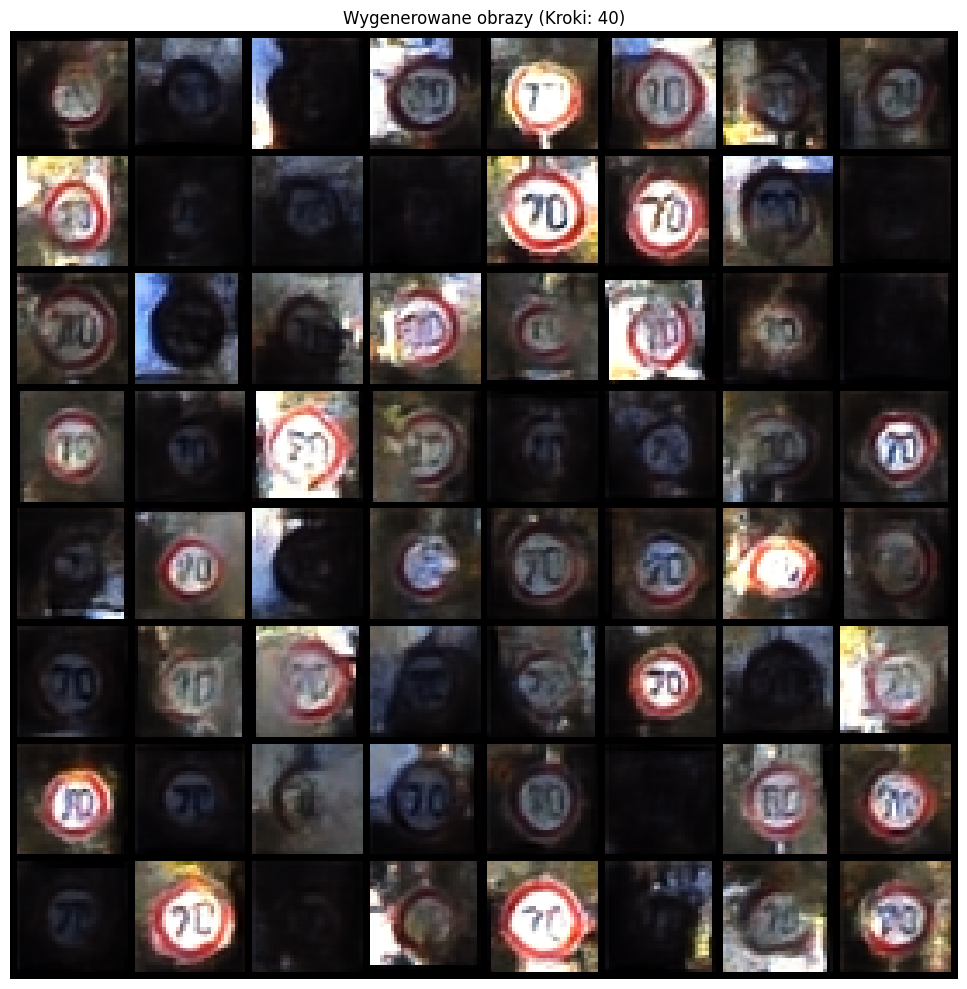

tensor([[[[ 2.7950e-02,  1.2837e-02,  1.6962e-02,  ...,  1.0200e-01,
            8.5260e-02,  1.0176e-01],
          [ 1.0367e-01,  9.1460e-02,  8.8669e-02,  ...,  3.0652e-01,
            3.1856e-01,  3.7924e-01],
          [ 1.4408e-01,  1.0003e-01,  9.5654e-02,  ...,  2.9656e-01,
            3.3858e-01,  3.6252e-01],
          ...,
          [ 7.8994e-02,  4.5005e-02,  3.6687e-02,  ...,  5.6958e-02,
            7.0172e-02,  9.3247e-02],
          [ 8.1766e-02,  4.7021e-02,  4.1312e-02,  ...,  5.5540e-02,
            6.1430e-02,  6.8847e-02],
          [ 5.2120e-02,  3.9605e-02,  3.2407e-02,  ...,  3.5899e-02,
            3.3194e-02,  3.8978e-02]],

         [[ 1.8438e-02,  6.0121e-03,  6.2519e-03,  ...,  6.2217e-02,
            4.5895e-02,  5.9885e-02],
          [ 9.3550e-02,  8.7578e-02,  8.3724e-02,  ...,  2.6471e-01,
            2.8151e-01,  3.4823e-01],
          [ 1.2831e-01,  8.9383e-02,  8.3845e-02,  ...,  2.4188e-01,
            2.9614e-01,  3.3096e-01],
          ...,
     

In [ ]:
generate_and_show_images(net, class_label=4, n_steps=40, n_samples=64)

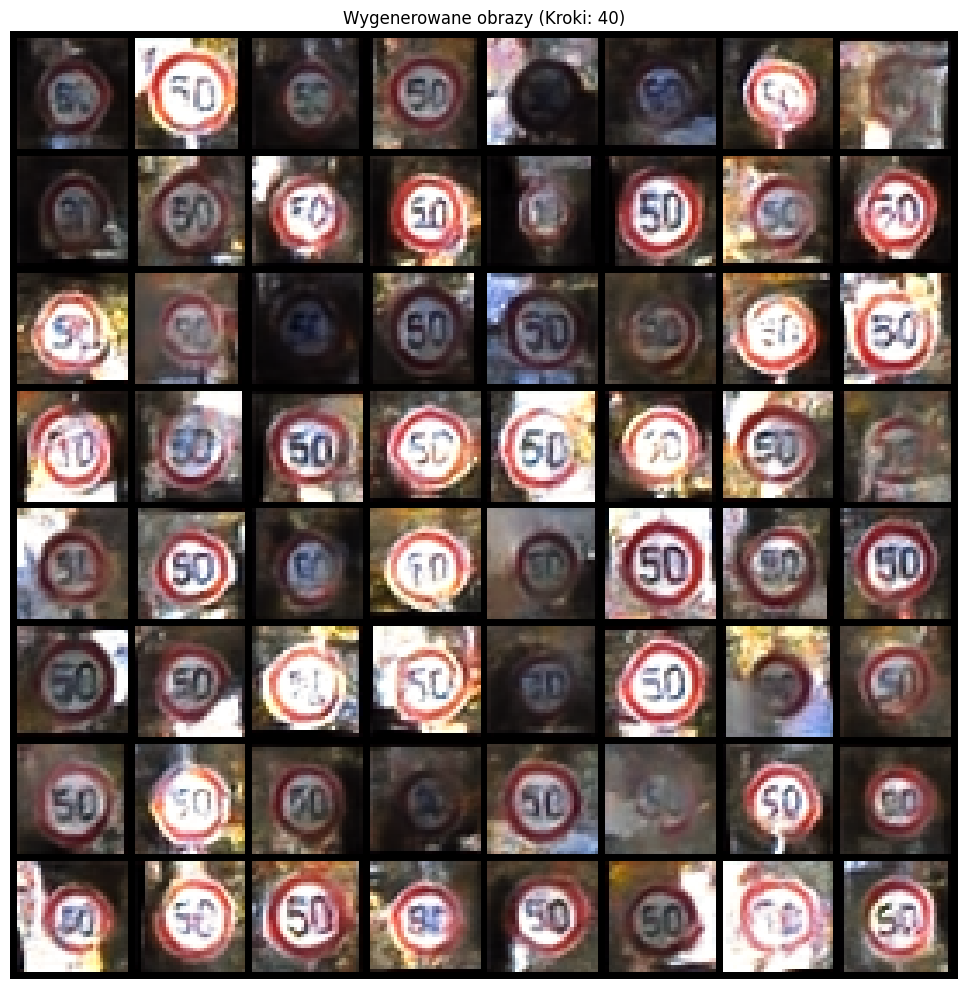

tensor([[[[ 7.5949e-02,  6.5922e-02,  9.6240e-02,  ...,  1.6709e-01,
            1.6223e-01,  1.3038e-01],
          [ 3.9999e-02,  3.0062e-02,  5.3977e-02,  ...,  1.4059e-01,
            1.4181e-01,  1.1805e-01],
          [ 4.5942e-02,  3.8855e-02,  5.8043e-02,  ...,  1.1954e-01,
            1.2958e-01,  1.1864e-01],
          ...,
          [ 1.5209e-01,  1.1637e-01,  1.1216e-01,  ...,  1.2471e-01,
            1.0981e-01,  1.0261e-01],
          [ 1.5906e-01,  1.2142e-01,  1.2172e-01,  ...,  1.2678e-01,
            8.6409e-02,  8.3327e-02],
          [ 1.4066e-01,  1.1921e-01,  1.2116e-01,  ...,  1.7421e-01,
            1.2047e-01,  8.4116e-02]],

         [[ 6.1245e-02,  5.3249e-02,  8.0911e-02,  ...,  1.2245e-01,
            1.2220e-01,  1.0148e-01],
          [ 3.1081e-02,  1.9391e-02,  4.3616e-02,  ...,  1.0599e-01,
            1.1087e-01,  9.7250e-02],
          [ 3.7522e-02,  3.1093e-02,  5.0627e-02,  ...,  9.5015e-02,
            1.1019e-01,  1.0279e-01],
          ...,
     

In [ ]:
generate_and_show_images(net, class_label=2, n_steps=40, n_samples=64)